In [48]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from simulator import simulator
from simulator.simulator import State, STATE_LO, STATE_HI
from simulator.logic74 import logic74 as L74

ms_1 = simulator.us(1)

s = simulator.system
s.clear()

s_clock = simulator.Clock(simulator.hz(10000))
# n0 = simulator.Inverter(clock.clock, ms_1, ms_1)
# n1 = simulator.Inverter(n0.output, ms_1, ms_1)
# a0 = simulator.And(n0.output, n1.output, ms_1, ms_1)

reset = State(simulator.LO)
c0 = simulator.BinaryCounter(2 * [STATE_LO],
                             s_clock.clock,
                             reset,
                             STATE_HI,
                             STATE_LO,
                             ms_1, ms_1, ms_1, ms_1, ms_1, ms_1)
c0.outputs = [State(simulator.LO) for _ in range(2)]
c0.terminal_count = State(simulator.LO)

c1 = simulator.BinaryCounter(2 * [STATE_LO],
                             s_clock.clock,
                             reset,
                             c0.terminal_count,
                             STATE_LO,
                             ms_1, ms_1, ms_1, ms_1, ms_1, ms_1)
c1.outputs = [State(simulator.LO) for _ in range(2)]
c1.terminal_count = State(simulator.LO)

tc1 = simulator.And(c0.terminal_count, c1.terminal_count, ms_1, ms_1)

c2 = simulator.BinaryCounter(2 * [STATE_LO],
                             s_clock.clock,
                             reset,
                             tc1.output,
                             STATE_LO,
                             ms_1, ms_1, ms_1, ms_1, ms_1, ms_1)
c2.outputs = [State(simulator.LO) for _ in range(2)]
c2.terminal_count = State(simulator.LO)

tc2 = simulator.And(tc1.output, c2.terminal_count, ms_1, ms_1)

c3 = simulator.BinaryCounter(2 * [STATE_LO],
                             s_clock.clock,
                             reset,
                             tc2.output,
                             STATE_LO,
                             ms_1, ms_1, ms_1, ms_1, ms_1, ms_1)
c3.outputs = [State(simulator.LO) for _ in range(2)]
c3.terminal_count = State(simulator.LO)

tc = simulator.And(tc2.output, c3.terminal_count, ms_1, ms_1)

duration = simulator.Timestamp(simulator.s(0.1).d)

while s.timestamp <= duration:
    dt = s.next_update()
    s.update(dt)

def to_datapoints(state: State, tag: str=''):
    for s in state.timeline:
        yield (tag, s.t_begin.t / 1e9, s.value)
        yield (tag, s.t_end.t / 1e9, s.value)

data = (list(to_datapoints(s_clock.clock, 'clk'))
        # + list(to_datapoints(n0.output, 'n0'))
        # + list(to_datapoints(n1.output, 'n1'))
        # + list(to_datapoints(a0.output, 'a0'))
        + list(to_datapoints(c0.outputs[0], 'c0.0'))
        + list(to_datapoints(c0.outputs[1], 'c0.1'))
        + list(to_datapoints(c0.terminal_count, 'c0.tc'))
        + list(to_datapoints(c1.outputs[0], 'c1.0'))
        + list(to_datapoints(c1.outputs[1], 'c1.1'))
        + list(to_datapoints(c1.terminal_count, 'c1.tc'))
        + list(to_datapoints(tc1.output, 'tc1'))
        + list(to_datapoints(c2.outputs[0], 'c2.0'))
        + list(to_datapoints(c2.outputs[1], 'c2.1'))
        + list(to_datapoints(c2.terminal_count, 'c2.tc'))
        + list(to_datapoints(tc2.output, 'tc2'))
        + list(to_datapoints(c3.outputs[0], 'c3.0'))
        + list(to_datapoints(c3.outputs[1], 'c3.1'))
        + list(to_datapoints(c3.terminal_count, 'c3.tc'))
        + list(to_datapoints(tc.output, 'tc')))

t = pd.DataFrame.from_records(data, columns=['tag', 't', 'level'])

(0.049, 0.05)

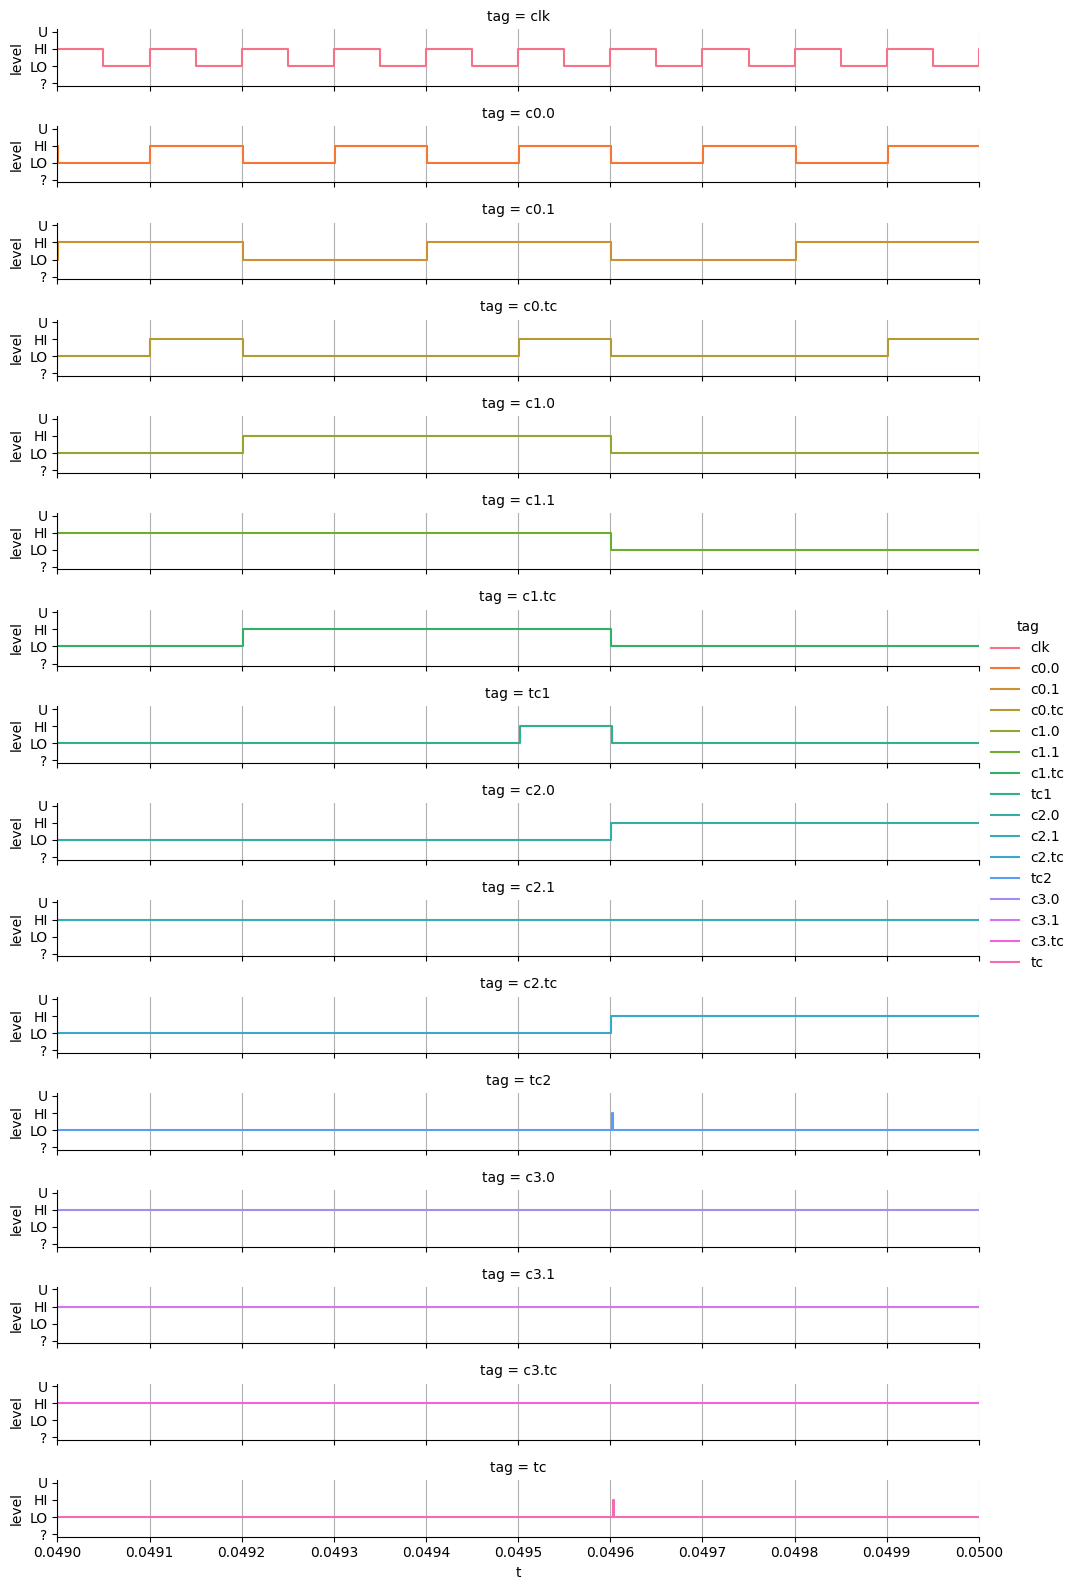

In [47]:
selector = (0.048 <= t['t'])|(t['t'] <= 0.052)
g = sns.relplot(t[selector], x='t', y='level', row='tag', hue='tag', kind='line', height=1, aspect=10, estimator=None, sort=False)

for ax in g.axes.flatten():
    ax.get_xaxis().set_major_locator(mpl.ticker.MultipleLocator(0.0001))
    ax.grid(axis='x')
plt.xlim([0.049, 0.050])

In [ ]:
class cpu4_ALU:
    def __init__(self, a: list[State], b: list[State], cin: State, is_logic: State, enable: State) -> None:
        self._adder = L74.HC283_Adder(a, b, cin)
        self._nand = L74.HC00_Nand(a,  b)
        self._muxer = L74.HC157_Mux2to1(self._adder.output, self._nand.output, is_logic, enable, STATE_LO)
        self.output = self._muxer.output

class cpu4_AddressRegister:
    def __init__(self, d: list[State], increment: State, load: State, n_reset: State, clock: State, n_select: State) -> None:
        assert len(d) == 12
        self._reg_0_4 = L74.HC161_Counter(d[0:4], increment, increment, load, n_reset, clock)
        self._reg_4_8 = L74.HC161_Counter(d[4:8], increment, self._reg_0_4.terminal_count, load, n_reset, clock)
        self._reg_8_B = L74.HC161_Counter(d[8:12], increment, self._reg_8_B.terminal_count, load, n_reset, clock)
        self._buffers = [L74.HC244_Buffer(self._reg_0_4[0].outputs, n_select, self._reg_4_8[1].outputs, n_select),
                         L74.HC244_Buffer(self._reg_8_B[2].outputs, n_select, [STATE_LO for _ in range(4)], STATE_HI)]
        self.outputs = (self._buffers[0].outputs_a
                        + self._buffers[0].outputs_b
                        + self._buffers[1].outputs_a)

class cpu4_AddressBuilder:
    def __init__(self, nibble0: list[State], nibble1: list[State], nibble2: list[State]) -> None:
        assert len(nibble0) == len(nibble1) == len(nibble2) == 4
        self.outputs = nibble0 + nibble1 + nibble2

d0 = simulator.Duration(0)

s_clock = simulator.Clock(simulator.hz(1))
s_n_clock = simulator.Inverter(s_clock, d0, d0)

s_reset = State()
s_n_reset = simulator.Inverter(s_reset, d0, d0)

s_addr_sel = State()
s_n_addr_sel = simulator.Inverter(s_addr_sel, d0, d0)

s_mar_n_sel = s_addr_sel
s_mar_inc = State()
s_mar_load = State()
s_mar_n_reset = s_n_reset
s_mar_clock = s_clock

s_pc_n_sel = s_n_addr_sel
s_pc_inc = State()
s_pc_load = State()
s_pc_n_reset = s_n_reset
s_pc_clock = s_clock

address_builder = cpu4_AddressBuilder()
mar = cpu4_AddressRegister(address_builder.outputs, s_mar_inc, s_mar_load, s_mar_n_reset, s_clock, s_addr_sel)
pc = cpu4_AddressRegister(address_builder.outputs, s_pc_inc, s_pc_load, s_pc_n_reset, s_pc_clock, s_pc_n_sel)

